# Least-Squares Problems

## 1. Problem Formulation

Consider an overdetermined linear system

$$
Ax=b,
$$

where

$$
A\in\mathbb{R}^{m\times n},
\qquad
b\in\mathbb{R}^{m},
\qquad
m>n.
$$

Because the system contains more equations than unknowns, an exact solution may not exist. Instead, we seek a vector $x$ such that $Ax$ is as close as possible to $b$.

The least-squares estimator is defined by

$$
x_{\mathrm{LS}}
=
\operatorname*{arg\,min}_{x\in\mathbb{R}^n}
\|Ax-b\|^2_2.
$$

The first-order optimality condition gives the normal equations

$$
A^TAx=A^Tb.
$$

Because forming $A^TA$ squares the condition number, this formulation is included both as a baseline and as an experiment in numerical sensitivity.




In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILENAME = "least_squares_practice_datasets.xlsx"
DATA_CANDIDATES = [
    Path("docs") / DATA_FILENAME,
    Path("../docs") / DATA_FILENAME,
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not find {DATA_FILENAME}. Run the notebook from the project root or src directory."
    )

np.set_printoptions(suppress=True, precision=8)
rng = np.random.default_rng(7)

## 2. Solving the Normal Equations with Cholesky Factorization

In [94]:
# Cholesky factorization of the symmetric positive-definite Gram matrix.
def cholesky_decomposition(A, symmetry_tol=1e-12):
    """Return the lower-triangular Cholesky factor of an SPD matrix."""
    A = np.asarray(A, dtype=float)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A must be a square matrix.")

    if not np.all(np.isfinite(A)):
        raise ValueError("A must contain only finite values.")

    if not np.allclose(A, A.T, atol=symmetry_tol, rtol=symmetry_tol):
        raise ValueError("A must be symmetric.")
    
    n = A.shape[0]
    L = np.zeros_like(A)

    for j in range (n):
        diag = A[j, j] - L[j, :j] @ L[j, :j]
        if diag <= symmetry_tol:
            raise ValueError("A must be positive definite.")
        L[j, j] = np.sqrt(diag)
        
        if j < n - 1:
            L[j + 1:, j] = (A[j + 1:, j] - L[j + 1:, :j] @ L[j, :j]) / L[j, j]
    return L

In [95]:
# Forward and backward substitution for the two triangular systems.

def forward_substitution(L, b):
    """Solve a lower-triangular system Ly = b."""
    b = np.asarray(b, dtype=float)
    n = L.shape[0]
    y = np.empty_like(b, dtype=float)
    for i in range(n):
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    return y

def backward_substitution(U, y):
    """Solve an upper-triangular system Ux = y."""
    y = np.asarray(y, dtype=float)
    n = U.shape[0]
    x = np.empty_like(y, dtype=float)
    for i in range(n - 1, -1, -1):
        if U[i, i] == 0:
            raise np.linalg.LinAlgError("Singular upper-triangular system.")
        x[i] = (y[i] - U[i, i + 1 :] @ x[i + 1 :]) / U[i, i]
    return x

def cholesky_solve(L, b):
    """Solve LL.T x = b from a precomputed Cholesky factor."""
    y = forward_substitution(L, b)
    x = backward_substitution(L.T, y)
    return x

In [96]:
def least_squares_normal_equations(A, b):
    """Solve a full-rank least-squares problem through the normal equations."""
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)

    gram_matrix = A.T @ A
    right_hand_side = A.T @ b

    L = cholesky_decomposition(gram_matrix)
    x = cholesky_solve(L, right_hand_side)

    return x

## 3. Verification

In [97]:
def least_squares_metrics(A, b, x):
    """Return residual and first-order optimality diagnostics."""
    residual = b - A @ x
    residual_norm = np.linalg.norm(residual,ord=2)
    orthogonality_error = np.linalg.norm(A.T @ residual,ord=2)
    normalized_orthogonality = (orthogonality_error/ (np.linalg.norm(A, ord=2)* np.linalg.norm(residual, ord=2)+ np.finfo(float).tiny))

    return {
        "residual": residual,
        "residual_norm": residual_norm,
        "orthogonality_error": orthogonality_error,
        "normalized_orthogonality": normalized_orthogonality
    }

In [98]:
# Create a reproducible overdetermined system (m > n).
m, n = 20, 5
A = rng.normal(size=(m, n))
x_true = rng.normal(size=n)
b = A @ x_true + 0.01 * rng.normal(size=m)

x = least_squares_normal_equations(A, b)
x_reference, *_ = np.linalg.lstsq(A, b, rcond=None)

residual = b - A @ x
orthogonality_error = np.linalg.norm(A.T @ residual)
solution_error = np.linalg.norm(x - x_reference)

assert np.allclose(x, x_reference, rtol=1e-10, atol=1e-12)
print(f"Orthogonality error: {orthogonality_error:.3e}")
print(f"Difference from np.linalg.lstsq: {solution_error:.3e}")

Orthogonality error: 6.835e-15
Difference from np.linalg.lstsq: 1.123e-15


## 4. Ordinary Linear Regression

This experiment fits a one-feature linear model and evaluates both the residual norm and the normal-equation optimality condition.

The design matrix includes a leading column of ones so that the first fitted coefficient represents the intercept.

### 4.1 Diagnostic Metrics

In [99]:
def linear_regression_diagnostics(A, b, beta):
    """Evaluate residual and optimality metrics for a fitted linear model."""
    return least_squares_metrics(A, b, beta)

### 4.2 Load the Dataset

In [100]:
linear_data = pd.read_excel(
    DATA_PATH,
    sheet_name="Linear Regression"
)

linear_data.head()

x_data = linear_data["x"].to_numpy(dtype=float)
b = linear_data["y_observed"].to_numpy(dtype=float)

### 4.3 Estimate the Regression Coefficients

In [101]:
A = np.column_stack((np.ones_like(x_data), x_data))
beta = least_squares_normal_equations(A, b)

print(f"Estimated intercept = {beta[0]:.6f}")
print(f"Estimated slope     = {beta[1]:.6f}")

intercept = 0.252112
slope     = 2.470613


### 4.4 Numerical Verification

In [102]:
metrics = linear_regression_diagnostics(A, b, beta)

print(
    f"residual norm = "
    f"{metrics['residual_norm']:.6e}"
)

print(
    f"orthogonality error = "
    f"{metrics['orthogonality_error']:.6e}"
)

print(
    f"normalized orthogonality = "
    f"{metrics['normalized_orthogonality']:.6e}"
)

residual norm = 1.352483e+01
orthogonality error = 3.489908e-13
normalized orthogonality = 6.945442e-16


### 4.5 Regression Fit and Residual Visualization


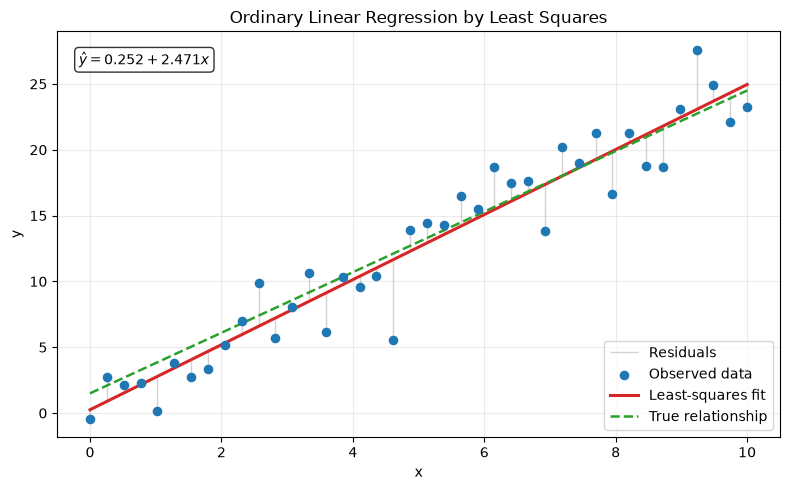

In [103]:
fitted_values = A @ beta
sort_order = np.argsort(x_data)

fig, ax = plt.subplots(figsize=(8, 5))

# Residuals are the vertical distances from observations to the fitted line.
ax.vlines(
    x_data,
    fitted_values,
    b,
    color="gray",
    alpha=0.35,
    linewidth=1,
    label="Residuals",
)
ax.scatter(x_data, b, color="tab:blue", s=35, label="Observed data", zorder=3)
ax.plot(
    x_data[sort_order],
    fitted_values[sort_order],
    color="tab:red",
    linewidth=2.2,
    label="Least-squares fit",
)

if "y_true" in linear_data.columns:
    y_true_data = linear_data["y_true"].to_numpy(dtype=float)
    ax.plot(
        x_data[sort_order],
        y_true_data[sort_order],
        color="tab:green",
        linestyle="--",
        linewidth=1.8,
        label="True relationship",
    )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Ordinary Linear Regression by Least Squares")
ax.text(
    0.03,
    0.95,
    rf"$\hat{{y}}={beta[0]:.3f}+{beta[1]:.3f}x$",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 5. Weighted Least Squares

Weighted least squares minimizes $\lVert W^{1/2}(Ax-b)\rVert_2^2$ and leads to the weighted normal equations

$$
\boxed{
A^TWA\hat{x}=A^TWb.
}
$$

### 5.1 Load the Dataset

In [104]:
weighted_data = pd.read_excel(
    DATA_PATH,
    sheet_name="Weighted LS"
)
x = weighted_data["x"].to_numpy(dtype=float)
b = weighted_data["y_observed"].to_numpy(dtype=float)
sigma = weighted_data["sigma"].to_numpy(dtype=float)
weights = weighted_data["weight"].to_numpy(dtype=float)
y_true = weighted_data["y_true"].to_numpy(dtype=float)

A = np.column_stack([np.ones(x.size),x])

weighted_data.head()


,observation_id,x,sigma,weight,y_observed,y_true,noise
0,1,0.000000,0.200000,25.000000,1.751223,2.000000,-0.248777
1,2,0.169492,0.225424,19.678896,2.172366,2.254237,-0.081872
2,3,0.338983,0.250847,15.892075,2.823896,2.508475,0.315421
3,4,0.508475,0.276271,13.101735,3.018043,2.762712,0.255331
4,5,0.677966,0.301695,10.986618,2.917599,3.016949,-0.099350


### 5.2 OLS Baseline

In [105]:
ols = least_squares_normal_equations(A, b)

print("OLS coefficients:", ols)

[1.84769737 1.55397181]


### 5.3 Weighted Least-Squares Estimate

Let the diagonal weight matrix be

$$
W = \operatorname{diag}(w_1, w_2, \ldots, w_m),
$$

and define its square root as

$$
\Omega = W^{1/2}
= \operatorname{diag}(\sqrt{w_1}, \sqrt{w_2}, \ldots, \sqrt{w_m}).
$$

Since $W = \Omega^T\Omega$, the weighted normal equations become

$$
A^T\Omega^T\Omega A\hat{x}
= A^T\Omega^T\Omega b.
$$

Equivalently,

$$
(\Omega A)^T(\Omega A)\hat{x}
= (\Omega A)^T(\Omega b).
$$


In [106]:
sqrt_weights = np.sqrt(weights)
A_weighted = sqrt_weights[:, None] * A
b_weighted = sqrt_weights * b

wls = least_squares_normal_equations(A_weighted, b_weighted)
print("WLS coefficients:", wls)

[1.94732195 1.52946995]


### 5.4 Parameter-Error Comparison


In [107]:
beta_true = np.array([2.0,1.5])
ols_parameter_error = np.linalg.norm(ols - beta_true)
wls_parameter_error = np.linalg.norm(wls - beta_true)

print(
    f"\nOLS parameter error = "
    f"{ols_parameter_error:.6e}"
)

print(
    f"WLS parameter error = "
    f"{wls_parameter_error:.6e}"
)


OLS parameter error = 1.615829e-01
WLS parameter error = 6.036104e-02


### 5.5 Model and Uncertainty Visualization


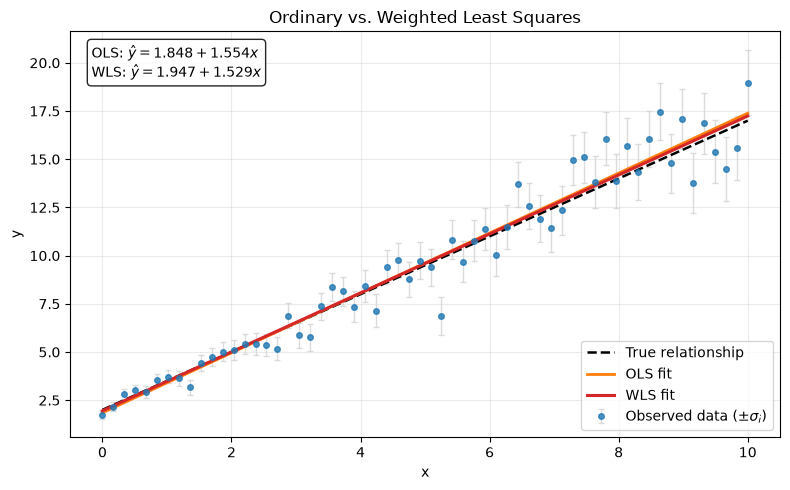

In [108]:
sort_order = np.argsort(x)
ols_fitted = A @ ols
wls_fitted = A @ wls

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    x,
    b,
    yerr=sigma,
    fmt="o",
    color="tab:blue",
    ecolor="lightgray",
    elinewidth=1,
    capsize=2,
    markersize=4,
    alpha=0.8,
    label=r"Observed data ($\pm\sigma_i$)",
)
ax.plot(
    x[sort_order],
    y_true[sort_order],
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="True relationship",
)
ax.plot(
    x[sort_order],
    ols_fitted[sort_order],
    color="tab:orange",
    linewidth=2,
    label="OLS fit",
)
ax.plot(
    x[sort_order],
    wls_fitted[sort_order],
    color="tab:red",
    linewidth=2.2,
    label="WLS fit",
)

equations = (
    rf"OLS: $\hat{{y}}={ols[0]:.3f}+{ols[1]:.3f}x$"
    "\n"
    rf"WLS: $\hat{{y}}={wls[0]:.3f}+{wls[1]:.3f}x$"
)
ax.text(
    0.03,
    0.97,
    equations,
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Ordinary vs. Weighted Least Squares")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Ridge Regularization for Ill-Conditioned Least-Squares Problems

### 6.1 Load the Dataset

In [109]:
ridge_data = pd.read_excel(
    DATA_PATH,
    sheet_name="Ridge Regression"
)

ridge_data.head()

train_data = ridge_data[ridge_data["split"] == "train"].reset_index(drop=True)
test_data = ridge_data[ridge_data["split"] == "test"].reset_index(drop=True)

features = ["x1", "x2", "x3"]

X_train = train_data[features].to_numpy(dtype=float)
y_train = train_data["y_observed"].to_numpy(dtype=float)

X_test = test_data[features].to_numpy(dtype=float)
y_test = test_data["y_observed"].to_numpy(dtype=float)

### 6.2 Standardize the Features

Use the training-set mean and standard deviation for both the training and test sets. This keeps the ridge penalty comparable across features and prevents information from the test set from influencing model fitting.

In [110]:
mean = X_train.mean(axis=0)
scale = X_train.std(axis=0)

X_train_scaled = (
    X_train - mean
) / scale

X_test_scaled = (
    X_test - mean
) / scale
A_train = np.column_stack([
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
])

A_test = np.column_stack([
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
])

### 6.3 OLS Baseline

Fit an unregularized least-squares model as a baseline. Because $x_1$ and $x_2$ are almost perfectly correlated, their individual OLS coefficients can be extremely unstable.

In [111]:
beta_ols, *_ = np.linalg.lstsq(
    A_train,
    y_train,
    rcond=None
)

### 6.4 Ridge Regression Implementation

Ridge regression solves

$$
(A^T A + \lambda P)\hat{\beta} = A^T y,
$$

where $P=\operatorname{diag}(0,1,\ldots,1)$ leaves the intercept unpenalized.

In [112]:
def ridge_regression(
    A,
    y,
    regularization
):
    """Fit ridge coefficients while leaving the intercept unpenalized."""
    n_parameters = A.shape[1]

    penalty = np.eye(n_parameters)

    # Do not penalize the intercept.
    penalty[0, 0] = 0.0

    matrix = (
        A.T @ A
        + regularization * penalty
    )

    right_hand_side = (
        A.T @ y
    )

    L = cholesky_decomposition(
        matrix
    )

    beta = cholesky_solve(
        L,
        right_hand_side
    )

    return beta

### 6.5 Fit the Regularized Model

In [113]:
regularization = 0.1

beta_ridge = ridge_regression(
    A_train,
    y_train,
    regularization
)

### 6.6 Coefficient and Prediction-Error Comparison

The fitted coefficients and prediction errors quantify the bias–variance trade-off. Ridge regularization is expected to reduce the extreme coefficient sensitivity caused by the near-collinearity of $x_1$ and $x_2$.

In [114]:
def root_mean_squared_error(y_true, y_predicted):
    """Return the root mean squared prediction error."""
    return np.sqrt(np.mean((y_true - y_predicted) ** 2))

ols_train_prediction = A_train @ beta_ols
ols_test_prediction = A_test @ beta_ols
ridge_train_prediction = A_train @ beta_ridge
ridge_test_prediction = A_test @ beta_ridge

coefficient_comparison = pd.DataFrame(
    {
        "OLS": beta_ols,
        f"Ridge (lambda={regularization:g})": beta_ridge,
    },
    index=["Intercept", *features],
)

error_comparison = pd.DataFrame(
    {
        "Train RMSE": [
            root_mean_squared_error(y_train, ols_train_prediction),
            root_mean_squared_error(y_train, ridge_train_prediction),
        ],
        "Test RMSE": [
            root_mean_squared_error(y_test, ols_test_prediction),
            root_mean_squared_error(y_test, ridge_test_prediction),
        ],
    },
    index=["OLS", f"Ridge (lambda={regularization:g})"],
)

print("Coefficient comparison:")
print(coefficient_comparison)
print("\nPrediction error comparison:")
print(error_comparison)
print(f"\nCorrelation between x1 and x2: {np.corrcoef(X_train[:, 0], X_train[:, 1])[0, 1]:.8f}")
print(f"Condition number of A^T A: {np.linalg.cond(A_train.T @ A_train):.3e}")

Coefficient comparison:
                 OLS  Ridge (lambda=0.1)
Intercept   0.727761            0.727761
x1        -80.407787            2.011118
x2         84.535202            2.112875
x3          0.488373            0.497747

Prediction error comparison:
                    Train RMSE  Test RMSE
OLS                   0.482338   0.487054
Ridge (lambda=0.1)    0.493088   0.472980

Correlation between x1 and x2: 0.99999922
Condition number of A^T A: 2.614e+06


### 6.7 Regularization-Path Visualization

The left panel shows how the feature coefficients shrink and stabilize as $\lambda$ increases. The right panel shows the corresponding training and test prediction errors.

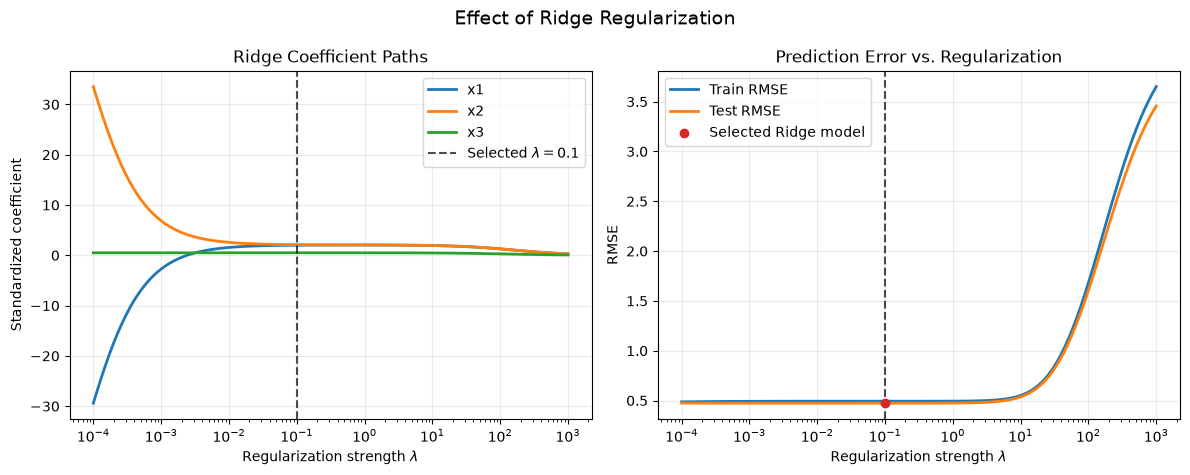

In [115]:
regularization_grid = np.logspace(-4, 3, 120)
coefficient_path = []
train_rmse_path = []
test_rmse_path = []

for lambda_value in regularization_grid:
    beta_value = ridge_regression(A_train, y_train, lambda_value)
    coefficient_path.append(beta_value)
    train_rmse_path.append(
        root_mean_squared_error(y_train, A_train @ beta_value)
    )
    test_rmse_path.append(
        root_mean_squared_error(y_test, A_test @ beta_value)
    )

coefficient_path = np.asarray(coefficient_path)
train_rmse_path = np.asarray(train_rmse_path)
test_rmse_path = np.asarray(test_rmse_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for feature_index, feature_name in enumerate(features, start=1):
    axes[0].plot(
        regularization_grid,
        coefficient_path[:, feature_index],
        linewidth=2,
        label=feature_name,
    )

axes[0].axvline(
    regularization,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=rf"Selected $\lambda={regularization:g}$",
)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"Regularization strength $\lambda$")
axes[0].set_ylabel("Standardized coefficient")
axes[0].set_title("Ridge Coefficient Paths")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    regularization_grid,
    train_rmse_path,
    linewidth=2,
    label="Train RMSE",
)
axes[1].plot(
    regularization_grid,
    test_rmse_path,
    linewidth=2,
    label="Test RMSE",
)
axes[1].axvline(
    regularization,
    color="black",
    linestyle="--",
    alpha=0.7,
)
axes[1].scatter(
    [regularization],
    [root_mean_squared_error(y_test, ridge_test_prediction)],
    color="tab:red",
    zorder=3,
    label="Selected Ridge model",
)
axes[1].set_xscale("log")
axes[1].set_xlabel(r"Regularization strength $\lambda$")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Prediction Error vs. Regularization")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle("Effect of Ridge Regularization", fontsize=14)
fig.tight_layout()
plt.show()